# Energy Analysis Offline Notebook

This notebook works entirely from previously saved JSON result files and does not query the Energy Information Service API. It loads both supply and demand records into pandas DataFrames and creates matching quarter-hour stacked plots for supply and demand.

Adjust `RESULTS_DIR`, `SUPPLY_JSON`, `DEMAND_JSON`, `FROM_TIME`, and `TO_TIME` below if your files live elsewhere or you want to limit the plotted time window.


In [139]:
# Setup: imports, env, config

from dotenv import load_dotenv
load_dotenv()

import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import cm
from matplotlib import dates as mdates
import pandas as pd
import seaborn as sns
import numpy as np

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14

RESULTS_DIR = Path(os.getenv('RESULTS_DIR', '../energy_information_service/results'))

def _latest_json(pattern: str, fallback: str) -> str:
    matches = sorted(RESULTS_DIR.glob(pattern))
    return matches[-1].name if matches else fallback

SUPPLY_JSON = os.getenv('SUPPLY_JSON', _latest_json('supply_forecast_*.json', 'supply.json'))
DEMAND_JSON = os.getenv('DEMAND_JSON', _latest_json('demand_forecast_*.json', 'demand.json'))

FIG_DIR = Path('figs')
OUT_DIR = Path('outputs')
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Results dir :', RESULTS_DIR)
print('Supply JSON :', RESULTS_DIR / SUPPLY_JSON)
print('Demand JSON :', RESULTS_DIR / DEMAND_JSON)

Results dir : ..\energy_information_service\results
Supply JSON : ..\energy_information_service\results\supply_forecast_2026-03-30.json
Demand JSON : ..\energy_information_service\results\demand_forecast_2025-11-12.json


In [140]:
# Load data from saved JSON files

import json

def load_records_from_json(json_name: str):
    path = RESULTS_DIR / json_name
    if not path.exists():
        raise FileNotFoundError(f'JSON input not found: {path}')

    payload = json.loads(path.read_text(encoding='utf-8'))
    if isinstance(payload, list):
        records = payload
    elif isinstance(payload, dict):
        if isinstance(payload.get('items'), list):
            records = payload['items']
        elif isinstance(payload.get('data'), list):
            records = payload['data']
        else:
            raise ValueError(f'Unsupported JSON object shape in {path}; expected list, items, or data')
    else:
        raise ValueError(f'Unsupported JSON root type in {path}: {type(payload).__name__}')

    frame = pd.json_normalize(records)
    if 'Time' in frame.columns:
        frame['Time'] = pd.to_datetime(frame['Time'])

    return frame.to_dict(orient='records')

supply_records = load_records_from_json(SUPPLY_JSON)
demand_records = load_records_from_json(DEMAND_JSON)

print('Supply records:', len(supply_records))
print('Demand records:', len(demand_records))


Supply records: 480
Demand records: 223


In [141]:
# Normalize JSON into DataFrames with the current API field names

def normalize_energy_records(records: list[dict], *, label: str) -> pd.DataFrame:
    df = pd.json_normalize(records)
    if df.empty:
        raise RuntimeError(f"{label} returned no rows.")

    time_candidates = [column for column in df.columns if "time" in column.lower() or "date" in column.lower()]
    if not time_candidates:
        raise RuntimeError(f"{label} has no timestamp-like column. Columns: {list(df.columns)}")

    time_col = time_candidates[0]
    value_candidates = ["Energy (kWh)", "energy_kwh", "energy_kwh_value"]
    value_col = next((column for column in value_candidates if column in df.columns), None)
    if value_col is None:
        raise RuntimeError(f"{label} has no Energy (kWh) column. Columns: {list(df.columns)}")

    source_col = "Source" if "Source" in df.columns else ("source" if "source" in df.columns else None)
    if source_col is None:
        df["Source"] = label
        source_col = "Source"

    keep_cols = [time_col, value_col, source_col]
    if "Cost (EUR/kWh)" in df.columns:
        keep_cols.append("Cost (EUR/kWh)")

    tidy = df[keep_cols].copy()
    tidy = tidy.rename(columns={time_col: "Time", value_col: "Energy (kWh)", source_col: "Source"})
    tidy["Time"] = pd.to_datetime(tidy["Time"])
    tidy["Energy (kWh)"] = pd.to_numeric(tidy["Energy (kWh)"], errors="coerce")
    return tidy.sort_values("Time").reset_index(drop=True)

supply_df = normalize_energy_records(supply_records, label="supply")
demand_df = normalize_energy_records(demand_records, label="demand")

print('Supply columns:', list(supply_df.columns))
print('Demand columns:', list(demand_df.columns))
display(supply_df.head())
display(demand_df.head())


Supply columns: ['Time', 'Energy (kWh)', 'Source', 'Cost (EUR/kWh)']
Demand columns: ['Time', 'Energy (kWh)', 'Source']


,Time,Energy (kWh),Source,Cost (EUR/kWh)
0,2026-03-30 16:00:00+02:00,4.04700,PV forecast,0.00000
1,2026-03-30 16:00:00+02:00,37.25000,Grid,0.00998
2,2026-03-30 16:15:00+02:00,3.69925,PV forecast,0.00000
3,2026-03-30 16:15:00+02:00,37.25000,Grid,0.02334
4,2026-03-30 16:30:00+02:00,3.33400,PV forecast,0.00000


,Time,Energy (kWh),Source
0,2025-11-12 01:00:00+01:00,1.817228,site
1,2025-11-12 01:15:00+01:00,1.817228,site
2,2025-11-12 01:30:00+01:00,1.817228,site
3,2025-11-12 01:45:00+01:00,1.817228,site
4,2025-11-12 02:00:00+01:00,1.690959,site


In [142]:
def shift_demand(supply_df: pd.DataFrame, demand_df: pd.DataFrame) -> pd.DataFrame:
    shifted_demand = demand_df.copy()

    if supply_df.empty or shifted_demand.empty:
        return shifted_demand

    supply_start = pd.to_datetime(supply_df["Time"].min())
    shifted_demand["Time"] = pd.to_datetime(shifted_demand["Time"])
    demand_start = shifted_demand["Time"].min()

    if supply_start.date() == demand_start.date():
        return shifted_demand.sort_values("Time")

    day_delta = (supply_start.date() - demand_start.date()).days
    shifted_demand["Time"] = shifted_demand["Time"] + pd.to_timedelta(day_delta, unit="D")
    return shifted_demand.sort_values("Time")

demand_df = shift_demand(supply_df, demand_df)
print('Supply start:', supply_df["Time"].min())
print('Demand start:', demand_df["Time"].min())

Supply start: 2026-03-30 16:00:00+02:00
Demand start: 2026-03-30 01:00:00+01:00


In [143]:
# Prepare quarter-hour pivot tables for plotting

def build_energy_pivot(df: pd.DataFrame, *, source_order: list[str] | None = None) -> pd.DataFrame:
    working = df.copy().set_index("Time").sort_index()
    pivot = working.reset_index().pivot_table(index="Time", columns="Source", values="Energy (kWh)", aggfunc="sum")

    if source_order is not None:
        ordered_columns = [source for source in source_order if source in pivot.columns]
        remaining_columns = [source for source in pivot.columns if source not in ordered_columns]
        pivot = pivot.reindex(columns=ordered_columns + remaining_columns)
    elif "Cost (EUR/kWh)" in working.columns:
        source_order = (
            working.reset_index()
            .groupby("Source")["Cost (EUR/kWh)"]
            .mean()
            .sort_values()
            .index
            .tolist()
        )
        pivot = pivot.reindex(columns=source_order)
    else:
        pivot = pivot.reindex(columns=sorted(pivot.columns))

    start = pivot.index.min().floor("h")
    end = pivot.index.max().ceil("15min")
    full_index = pd.date_range(start=start, end=end, freq="15min")

    return pivot.reindex(full_index).fillna(0)

def build_cost_pivot(df: pd.DataFrame, *, source_order: list[str] | None = None) -> pd.DataFrame:
    if "Cost (EUR/kWh)" not in df.columns:
        raise RuntimeError("Cost pivot requires a 'Cost (EUR/kWh)' column")

    working = df.copy().set_index("Time").sort_index()
    pivot = working.reset_index().pivot_table(index="Time", columns="Source", values="Cost (EUR/kWh)", aggfunc="mean")

    if source_order is not None:
        ordered_columns = [source for source in source_order if source in pivot.columns]
        remaining_columns = [source for source in pivot.columns if source not in ordered_columns]
        pivot = pivot.reindex(columns=ordered_columns + remaining_columns)
    else:
        pivot = pivot.reindex(columns=sorted(pivot.columns))

    start = pivot.index.min().floor("h")
    end = pivot.index.max().ceil("15min")
    full_index = pd.date_range(start=start, end=end, freq="15min")

    return pivot.reindex(full_index)

def build_residual_availability(
    supply_df: pd.DataFrame,
    demand_df: pd.DataFrame,
    *,
    source_order: list[str] | None = None,
) -> pd.DataFrame:
    demand_by_time = demand_df.groupby("Time", as_index=True)["Energy (kWh)"].sum().sort_index()
    residual_rows: list[dict] = []

    for time, supply_slice in supply_df.groupby("Time", sort=True):
        remaining_demand = float(demand_by_time.get(time, 0.0))
        working = supply_slice.copy()
        if source_order is not None:
            rank = {source: index for index, source in enumerate(source_order)}
            working["_source_rank"] = working["Source"].map(rank).fillna(len(rank))
            working = working.sort_values(["_source_rank", "Source"], kind="stable")
            working = working.drop(columns=["_source_rank"])
        elif "Cost (EUR/kWh)" in working.columns:
            working = working.sort_values(["Cost (EUR/kWh)", "Source"], kind="stable", na_position="last")
        else:
            working = working.sort_values(["Source"], kind="stable")

        for _, row in working.iterrows():
            available_energy = float(row["Energy (kWh)"])
            if available_energy <= 0:
                continue

            used_energy = min(remaining_demand, available_energy)
            residual_energy = available_energy - used_energy

            if used_energy > 0:
                used_row = row.to_dict()
                used_row["Energy (kWh)"] = -used_energy
                residual_rows.append(used_row)

            if residual_energy > 0:
                residual_row = row.to_dict()
                residual_row["Energy (kWh)"] = residual_energy
                residual_rows.append(residual_row)

            remaining_demand = max(0.0, remaining_demand - used_energy)

    residual_availability = pd.DataFrame(residual_rows)
    if residual_availability.empty:
        return pd.DataFrame(columns=supply_df.columns)

    residual_availability["Time"] = pd.to_datetime(residual_availability["Time"])
    residual_availability["Energy (kWh)"] = pd.to_numeric(residual_availability["Energy (kWh)"], errors="coerce")
    return residual_availability.sort_values(["Time", "Energy (kWh)", "Source"], ascending=[True, True, True]).reset_index(drop=True)

def build_residual_pivot(residual_df: pd.DataFrame, *, source_order: list[str]) -> pd.DataFrame:
    working = residual_df.copy()
    working["Residual component"] = working["Energy (kWh)"].apply(
        lambda value: "used" if float(value) < 0 else "available"
    )
    working["Residual source"] = working["Source"] + " | " + working["Residual component"]

    component_order = [f"{source} | used" for source in source_order] + [f"{source} | available" for source in source_order]
    pivot = (
        working.pivot_table(
            index="Time",
            columns="Residual source",
            values="Energy (kWh)",
            aggfunc="sum",
        )
        .reindex(columns=[column for column in component_order if column in working["Residual source"].unique()])
    )

    start = pivot.index.min().floor("h")
    end = pivot.index.max().ceil("15min")
    full_index = pd.date_range(start=start, end=end, freq="15min")
    return pivot.reindex(full_index).fillna(0)

def _cost_for_demand_at_time(
    supply_slice: pd.DataFrame,
    demand_energy_kwh: float,
    *,
    source_order: list[str],
) -> float:
    if demand_energy_kwh <= 0:
        return 0.0

    rank = {source: index for index, source in enumerate(source_order)}
    working = supply_slice.copy()
    working["_source_rank"] = working["Source"].map(rank).fillna(len(rank))
    working = working.sort_values(["_source_rank", "Source"], kind="stable")

    remaining_demand = float(demand_energy_kwh)
    total_cost = 0.0

    for _, row in working.iterrows():
        available_energy = max(0.0, float(row["Energy (kWh)"]))
        if available_energy <= 0:
            continue

        used_energy = min(remaining_demand, available_energy)
        total_cost += used_energy * float(row["Cost (EUR/kWh)"])
        remaining_demand -= used_energy

        if remaining_demand <= 1e-9:
            return total_cost

    return np.nan

def build_demand_cost_frame(
    supply_df: pd.DataFrame,
    demand_df: pd.DataFrame,
    *,
    source_order: list[str],
    delta_kw: float = 5.0,
) -> pd.DataFrame:
    delta_energy_kwh = float(delta_kw) * 0.25
    demand_by_time = demand_df.groupby("Time", as_index=True)["Energy (kWh)"].sum().sort_index()
    records: list[dict] = []

    for time, demand_energy in demand_by_time.items():
        supply_slice = supply_df.loc[supply_df["Time"] == time]
        if supply_slice.empty:
            continue

        base_cost = _cost_for_demand_at_time(supply_slice, float(demand_energy), source_order=source_order)
        increase_cost = _cost_for_demand_at_time(
            supply_slice,
            float(demand_energy) + delta_energy_kwh,
            source_order=source_order,
        )
        decrease_cost = _cost_for_demand_at_time(
            supply_slice,
            max(0.0, float(demand_energy) - delta_energy_kwh),
            source_order=source_order,
        )

        base_specific_cost = base_cost / float(demand_energy) if pd.notna(base_cost) and float(demand_energy) > 0 else np.nan
        increased_energy = float(demand_energy) + delta_energy_kwh
        increased_specific_cost = increase_cost / increased_energy if pd.notna(increase_cost) and increased_energy > 0 else np.nan
        decreased_energy = max(0.0, float(demand_energy) - delta_energy_kwh)
        decreased_specific_cost = decrease_cost / decreased_energy if pd.notna(decrease_cost) and decreased_energy > 0 else np.nan

        records.append(
            {
                "Time": pd.Timestamp(time),
                "Specific cost of demand (EUR/kWh)": base_specific_cost,
                "Specific cost of demand (+5 kW) (EUR/kWh)": increased_specific_cost,
                "Specific cost of demand (-5 kW) (EUR/kWh)": decreased_specific_cost,
            }
        )

    if not records:
        return pd.DataFrame(
            columns=[
                "Time",
                "Specific cost of demand (EUR/kWh)",
                "Specific cost of demand (+5 kW) (EUR/kWh)",
                "Specific cost of demand (-5 kW) (EUR/kWh)",
            ]
        )

    return pd.DataFrame(records).sort_values("Time").reset_index(drop=True)

SOURCE_ORDER = ["PV forecast", "Grid", "Grid forecast"]

supply_pivot = build_energy_pivot(supply_df)
supply_cost_pivot = build_cost_pivot(supply_df, source_order=list(supply_pivot.columns))
demand_pivot = build_energy_pivot(demand_df)
residual_availability = build_residual_availability(
    supply_df,
    demand_df,
    source_order=SOURCE_ORDER,
)
residual_pivot = build_residual_pivot(
    residual_availability,
    source_order=SOURCE_ORDER,
)
demand_costs = build_demand_cost_frame(
    supply_df,
    demand_df,
    source_order=SOURCE_ORDER,
    delta_kw=5.0,
)

print('Supply plot shape:', supply_pivot.shape)
print('Demand plot shape:', demand_pivot.shape)
print('Residual availability rows:', len(residual_availability))
display(supply_pivot.head())
display(demand_pivot.head())
display(residual_availability.head(12))
display(residual_pivot.head())
display(demand_costs.head())


Supply plot shape: (240, 3)
Demand plot shape: (192, 2)
Residual availability rows: 494


Source,PV forecast,Grid,Grid forecast
2026-03-30 16:00:00+02:00,4.04700,37.25,0.0
2026-03-30 16:15:00+02:00,3.69925,37.25,0.0
2026-03-30 16:30:00+02:00,3.33400,37.25,0.0
2026-03-30 16:45:00+02:00,2.94350,37.25,0.0
2026-03-30 17:00:00+02:00,2.54750,37.25,0.0


Source,production,site
2026-03-30 01:00:00+01:00,0.0,1.817228
2026-03-30 01:15:00+01:00,0.0,1.817228
2026-03-30 01:30:00+01:00,0.0,1.817228
2026-03-30 01:45:00+01:00,0.0,1.817228
2026-03-30 02:00:00+01:00,0.0,1.690959


,Time,Energy (kWh),Source,Cost (EUR/kWh)
0,2026-03-30 16:00:00+02:00,-2.50190,PV forecast,0.00000
1,2026-03-30 16:00:00+02:00,1.54510,PV forecast,0.00000
2,2026-03-30 16:00:00+02:00,37.25000,Grid,0.00998
3,2026-03-30 16:15:00+02:00,-2.50190,PV forecast,0.00000
4,2026-03-30 16:15:00+02:00,1.19735,PV forecast,0.00000
5,2026-03-30 16:15:00+02:00,37.25000,Grid,0.02334
6,2026-03-30 16:30:00+02:00,-2.50190,PV forecast,0.00000
7,2026-03-30 16:30:00+02:00,0.83210,PV forecast,0.00000
8,2026-03-30 16:30:00+02:00,37.25000,Grid,0.04426
9,2026-03-30 16:45:00+02:00,-2.50190,PV forecast,0.00000


Residual source,PV forecast | used,Grid | used,Grid forecast | used,PV forecast | available,Grid | available,Grid forecast | available
2026-03-30 16:00:00+02:00,-2.501900,0.0,0.0,1.545100,37.25,0.0
2026-03-30 16:15:00+02:00,-2.501900,0.0,0.0,1.197350,37.25,0.0
2026-03-30 16:30:00+02:00,-2.501900,0.0,0.0,0.832100,37.25,0.0
2026-03-30 16:45:00+02:00,-2.501900,0.0,0.0,0.441600,37.25,0.0
2026-03-30 17:00:00+02:00,-2.307348,0.0,0.0,0.240152,37.25,0.0


,Time,Specific cost of demand (EUR/kWh),Specific cost of demand (+5 kW) (EUR/kWh),Specific cost of demand (-5 kW) (EUR/kWh)
0,2026-03-30 15:00:00+01:00,0.0,0.000000,0.0
1,2026-03-30 15:15:00+01:00,0.0,0.000328,0.0
2,2026-03-30 15:30:00+01:00,0.0,0.004930,0.0
3,2026-03-30 15:45:00+01:00,0.0,0.013574,0.0
4,2026-03-30 16:00:00+01:00,0.0,0.012905,0.0


In [144]:
# Supply plot: stacked quarter-hour energy by source

def plot_stacked_energy(
    pivot: pd.DataFrame,
    *,
    title: str,
    filename: str,
    cost_pivot: pd.DataFrame | None = None,
    demand_pivot: pd.DataFrame | None = None,
):
    fig, ax = plt.subplots(figsize=(14, 6))
    x_positions = np.arange(len(pivot.index))

    if cost_pivot is None:
        colors = sns.color_palette("tab10", n_colors=len(pivot.columns))
        pivot.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.95)
    else:
        cost_aligned = cost_pivot.reindex(pivot.index).reindex(columns=pivot.columns)
        price_values = cost_aligned.to_numpy(dtype=float)
        finite_prices = price_values[np.isfinite(price_values)]
        if finite_prices.size == 0:
            raise RuntimeError("Price-colored stacked plot requires cost values")

        norm = mcolors.Normalize(vmin=float(finite_prices.min()), vmax=float(finite_prices.max()))
        cmap = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)
        bottom = np.zeros(len(pivot.index), dtype=float)

        for column in pivot.columns:
            values = pivot[column].to_numpy(dtype=float)
            prices = cost_aligned[column].to_numpy(dtype=float)
            bar_colors = [cmap(norm(price)) if np.isfinite(price) else (0.85, 0.85, 0.85, 0.9) for price in prices]
            ax.bar(x_positions, values, bottom=bottom, width=1, color=bar_colors, label=column, linewidth=0.0)
            bottom = bottom + values

        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        colorbar = fig.colorbar(sm, ax=ax, pad=0.02)
        colorbar.set_label("Cost (EUR/kWh)")

    if demand_pivot is not None:
        demand_total = demand_pivot.reindex(pivot.index).fillna(0).sum(axis=1)
        ax.plot(x_positions, demand_total.to_numpy(), color="#1f1f1f", linewidth=2.2, label="Total demand")

    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Energy (kWh) per 15 min")
    ax.legend(title="Source", bbox_to_anchor=(1.02, 1), loc="upper left")
    tick_step = max(1, len(pivot) // 12)
    tick_positions = range(0, len(pivot.index), tick_step)
    ax.set_xticks(list(tick_positions))
    ax.set_xticklabels([pivot.index[i].isoformat(timespec="seconds") for i in tick_positions], rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=150, bbox_inches="tight")
    return fig, ax


C:\Users\a.clement\AppData\Local\Temp\ipykernel_14676\1043733412.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.8))


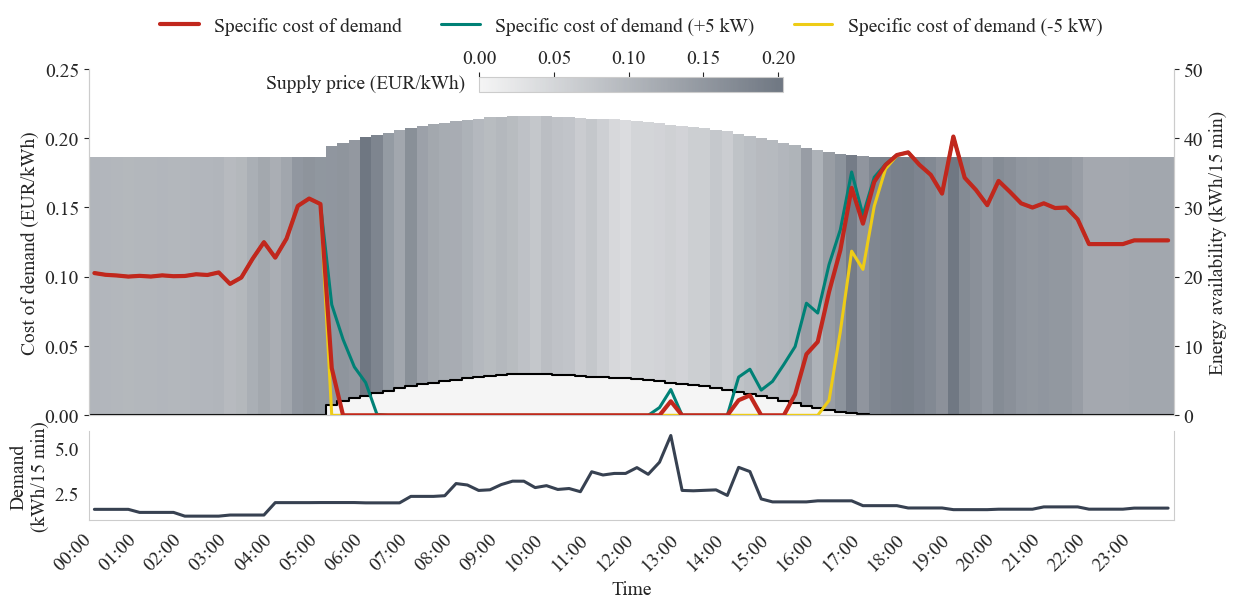

In [164]:
# Net plot: supply above zero, demand below zero

def plot_supply_with_specific_demand_cost(
    supply_pivot: pd.DataFrame,
    supply_cost_pivot: pd.DataFrame,
    demand_pivot: pd.DataFrame,
    demand_costs: pd.DataFrame,
    *,
    start_date: str,
    pv_label_x: int | None = None,
    pv_label_y_offset: float = 0.0,
    grid_label_x: int | None = None,
    grid_label_y_offset: float = 0.0,
    title: str,
    filename: str,
):
    def _to_utc_datetime_index(index_like) -> pd.DatetimeIndex:
        return pd.DatetimeIndex(pd.to_datetime(index_like, utc=True))

    cost_frame = demand_costs.copy()
    cost_frame["Time"] = pd.to_datetime(cost_frame["Time"], utc=True)
    cost_frame = cost_frame.set_index("Time")

    combined_index = supply_pivot.index.union(cost_frame.index).union(demand_pivot.index)
    combined_index = _to_utc_datetime_index(combined_index).sort_values()

    supply_aligned = supply_pivot.copy()
    supply_aligned.index = _to_utc_datetime_index(supply_aligned.index)
    supply_aligned = supply_aligned.reindex(combined_index).fillna(0)

    supply_cost_aligned = supply_cost_pivot.copy()
    supply_cost_aligned.index = _to_utc_datetime_index(supply_cost_aligned.index)
    supply_cost_aligned = supply_cost_aligned.reindex(combined_index).reindex(columns=supply_aligned.columns)

    specific_costs_aligned = cost_frame.reindex(combined_index)

    demand_aligned = demand_pivot.copy()
    demand_aligned.index = _to_utc_datetime_index(demand_aligned.index)
    demand_total_aligned = demand_aligned.reindex(combined_index).fillna(0).sum(axis=1)

    window_start = None
    if start_date:
        requested_start = pd.Timestamp(start_date)
        if combined_index.tz is not None:
            if requested_start.tzinfo is None:
                requested_start = requested_start.tz_localize(combined_index.tz)
            else:
                requested_start = requested_start.tz_convert(combined_index.tz)
        start_candidates = combined_index[combined_index >= requested_start]
        if len(start_candidates) > 0:
            window_start = start_candidates[0]
    else:
        start_candidates = combined_index[combined_index.strftime("%H:%M") == "00:00"]
        if len(start_candidates) > 0:
            window_start = start_candidates[0]

    if window_start is not None:
        window_end = window_start + pd.Timedelta(days=1) - pd.Timedelta(minutes=15)
        window_mask = (combined_index >= window_start) & (combined_index <= window_end)
        combined_index = combined_index[window_mask]
        supply_aligned = supply_aligned.reindex(combined_index)
        supply_cost_aligned = supply_cost_aligned.reindex(combined_index)
        specific_costs_aligned = specific_costs_aligned.reindex(combined_index)
        demand_total_aligned = demand_total_aligned.reindex(combined_index)

    base_specific_cost = specific_costs_aligned["Specific cost of demand (EUR/kWh)"]
    plus_specific_cost = specific_costs_aligned["Specific cost of demand (+5 kW) (EUR/kWh)"]
    minus_specific_cost = specific_costs_aligned["Specific cost of demand (-5 kW) (EUR/kWh)"]

    price_values = supply_cost_aligned.to_numpy(dtype=float)
    finite_prices = price_values[np.isfinite(price_values)]
    if finite_prices.size == 0:
        raise RuntimeError("Combined supply and specific-cost plot requires supply cost values")

    norm = mcolors.Normalize(vmin=float(finite_prices.min()), vmax=float(finite_prices.max()))
    cmap = sns.blend_palette(["#f3f3f3", "#4b5563"], as_cmap=True)

    fig, (ax_cost, ax_demand) = plt.subplots(
        2,
        1,
        figsize=(14, 6.2),
        sharex=True,
        gridspec_kw={"height_ratios": [4.2, 1], "hspace": 0.07},
    )
    ax_energy = ax_cost.twinx()
    ax_energy.set_zorder(1)
    ax_cost.set_zorder(2)
    ax_cost.patch.set_alpha(0)
    line_colors = ["#c1271d", "#008176", "#eecc16"]
    x_positions = np.arange(len(combined_index))
    bottom = np.zeros(len(combined_index), dtype=float)

    for column in supply_aligned.columns:
        values = supply_aligned[column].to_numpy(dtype=float)
        prices = supply_cost_aligned[column].to_numpy(dtype=float)
        bar_colors = [cmap(norm(price)) if np.isfinite(price) else (0.85, 0.85, 0.85, 0.9) for price in prices]
        ax_energy.bar(
            x_positions,
            values,
            bottom=bottom,
            width=1,
            color=bar_colors,
            linewidth=0,
            alpha=0.8,
            label=column,
            zorder=1,
        )
        bottom = bottom + values

    def _label_stack(
        column: str,
        text: str,
        *,
        x_index: int | None = None,
        y_offset: float = 0.0,
        color: str = "#1f1f1f",
    ) -> None:
        if column not in supply_aligned.columns or len(x_positions) == 0:
            return
        values = supply_aligned[column].to_numpy(dtype=float)
        valid_positions = np.flatnonzero(values > 0)
        if len(valid_positions) == 0:
            return
        if x_index is not None:
            label_pos = int(np.clip(x_index, 0, len(x_positions) - 1))
            if values[label_pos] <= 0:
                nearest = valid_positions[np.argmin(np.abs(valid_positions - label_pos))]
                label_pos = int(nearest)
        else:
            label_pos = int(valid_positions[len(valid_positions) // 2])
        lower = supply_aligned.loc[:, :column].sum(axis=1).to_numpy(dtype=float) - values
        y_pos = lower[label_pos] + values[label_pos] / 2 + y_offset
        ax_energy.text(
            x_positions[label_pos],
            y_pos,
            text,
            ha="center",
            va="center",
            color=color,
            fontsize=11,
            zorder=3,
        )

    #_label_stack("PV forecast", "PV generation", x_index=pv_label_x, y_offset=pv_label_y_offset)
    #_label_stack("Grid", "Grid supply", x_index=grid_label_x, y_offset=grid_label_y_offset)

    if "PV forecast" in supply_aligned.columns and "Grid" in supply_aligned.columns:
        pv_boundary = supply_aligned["PV forecast"].to_numpy(dtype=float)
        pv_step_x = np.append(x_positions - 0.5, x_positions[-1] + 0.5)
        pv_step_y = np.append(pv_boundary, pv_boundary[-1])
        ax_energy.step(
            pv_step_x,
            pv_step_y,
            where="post",
            color="#000000",
            linewidth=1.5,
            zorder=2,
        )
        ax_energy.vlines(
            x_positions[-1] + 0.5,
            ymin=0,
            ymax=pv_boundary[-1],
            color="#000000",
            linewidth=1.5,
            zorder=2,
        )

    ax_cost.plot(
        x_positions,
        base_specific_cost.to_numpy(dtype=float),
        color=line_colors[0],
        linewidth=3.0,
        label="Specific cost of demand",
        zorder=5,
    )
    ax_cost.plot(
        x_positions,
        plus_specific_cost.to_numpy(dtype=float),
        color=line_colors[1],
        linewidth=2.2,
        label="Specific cost of demand (+5 kW)",
        zorder=4.9,
    )
    ax_cost.plot(
        x_positions,
        minus_specific_cost.to_numpy(dtype=float),
        color=line_colors[2],
        linewidth=2.2,
        label="Specific cost of demand (-5 kW)",
        zorder=4.9,
    )
    ax_cost.set_title("")
    ax_cost.set_xlabel("")
    ax_cost.set_ylabel("Cost of demand (EUR/kWh)")
    ax_cost.set_ylim(0, 0.25)
    ax_energy.set_ylabel("Energy availability (kWh/15 min)")
    ax_energy.set_ylim(0, 50)
    ax_cost.grid(False)
    ax_energy.grid(False)
    ax_cost.margins(x=0)
    ax_energy.margins(x=0)
    ax_demand.margins(x=0)
    ax_cost.set_xlim(-0.5, len(combined_index) - 0.5)
    ax_cost.spines['top'].set_visible(False)
    ax_energy.spines['top'].set_visible(False)
    ax_demand.spines['top'].set_visible(False)

    ax_demand.plot(
        x_positions,
        demand_total_aligned.to_numpy(dtype=float),
        color="#374151",
        linewidth=2.2,
        label="Demand",
        zorder=3,
    )
    ax_demand.set_ylabel("Demand\n(kWh/15 min)")
    ax_demand.grid(False)

    tick_positions = [i for i, ts in enumerate(combined_index) if ts.minute == 0]
    if not tick_positions:
        tick_step = max(1, len(combined_index) // 12)
        tick_positions = list(range(0, len(combined_index), tick_step))
    ax_demand.set_xticks(tick_positions)
    ax_demand.set_xticklabels([combined_index[i].strftime("%H:%M") for i in tick_positions], rotation=45, ha="right")
    ax_cost.tick_params(axis="x", labelbottom=False)
    ax_demand.set_xlabel("Time")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    colorbar = fig.colorbar(sm, ax=ax_energy, orientation="horizontal", location="top", pad=0.02, fraction=0.05, shrink=0.28, alpha=0.8)
    colorbar.set_label("")
    colorbar_box = colorbar.ax.get_position()
    colorbar.ax.set_position([colorbar_box.x0, colorbar_box.y0 - 0.05, colorbar_box.width, colorbar_box.height])
    colorbar_box = colorbar.ax.get_position()
    fig.text(colorbar_box.x0 - 0.01, colorbar_box.y0 + colorbar_box.height / 2, "Supply price (EUR/kWh)", ha="right", va="center")

    handles_cost, labels_cost = ax_cost.get_legend_handles_labels()
    handles_energy, labels_energy = ax_energy.get_legend_handles_labels()
    filtered_energy = [(handle, label) for handle, label in zip(handles_energy, labels_energy) if label not in {'PV forecast', 'Grid', 'Grid forecast'}]
    filtered_handles_energy = [handle for handle, _ in filtered_energy]
    filtered_labels_energy = [label for _, label in filtered_energy]
    ax_energy.legend(handles_cost + filtered_handles_energy, labels_cost + filtered_labels_energy, title="", loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=4, frameon=False)
    fig.tight_layout(rect=(0, 0, 1, 0.8))
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    return fig, (ax_cost, ax_energy, ax_demand)


plot_supply_with_specific_demand_cost(
    supply_pivot,
    supply_cost_pivot,
    demand_pivot,
    demand_costs,
    title="Supply Forecast by Source with Specific Demand Cost",
    filename="supply_with_specific_demand_cost.png",
    start_date="2026-03-31",
    pv_label_x=None,
    pv_label_y_offset=1.0,
    grid_label_x=None,
    grid_label_y_offset=0.0,
)
plt.show()


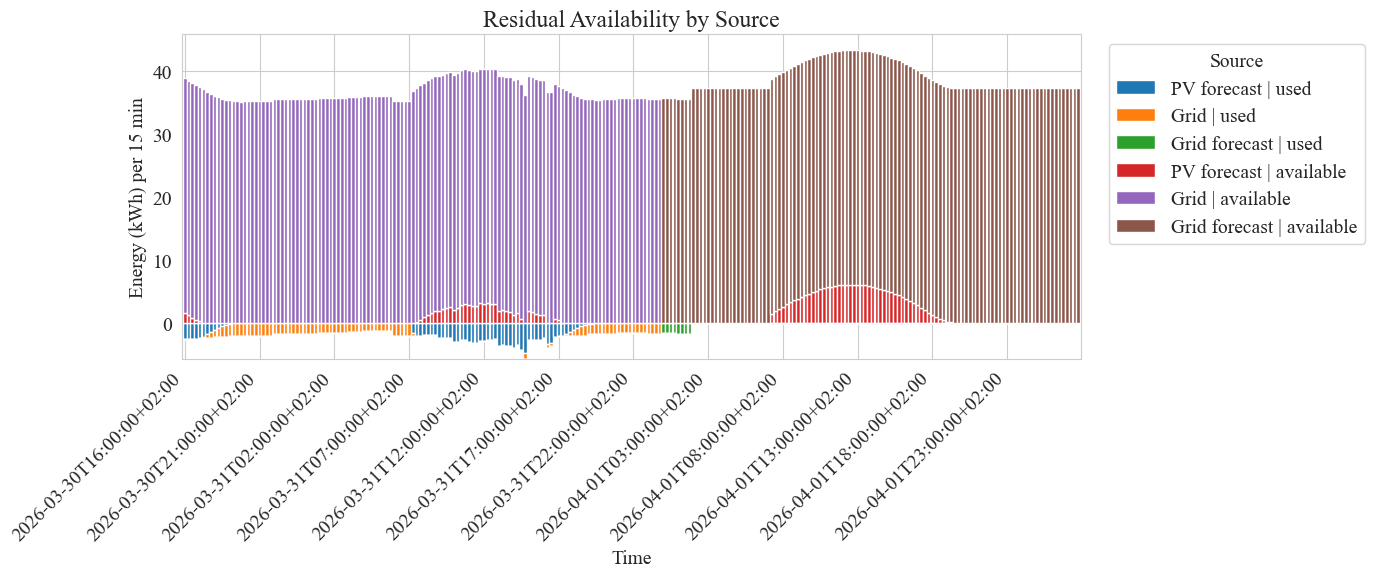

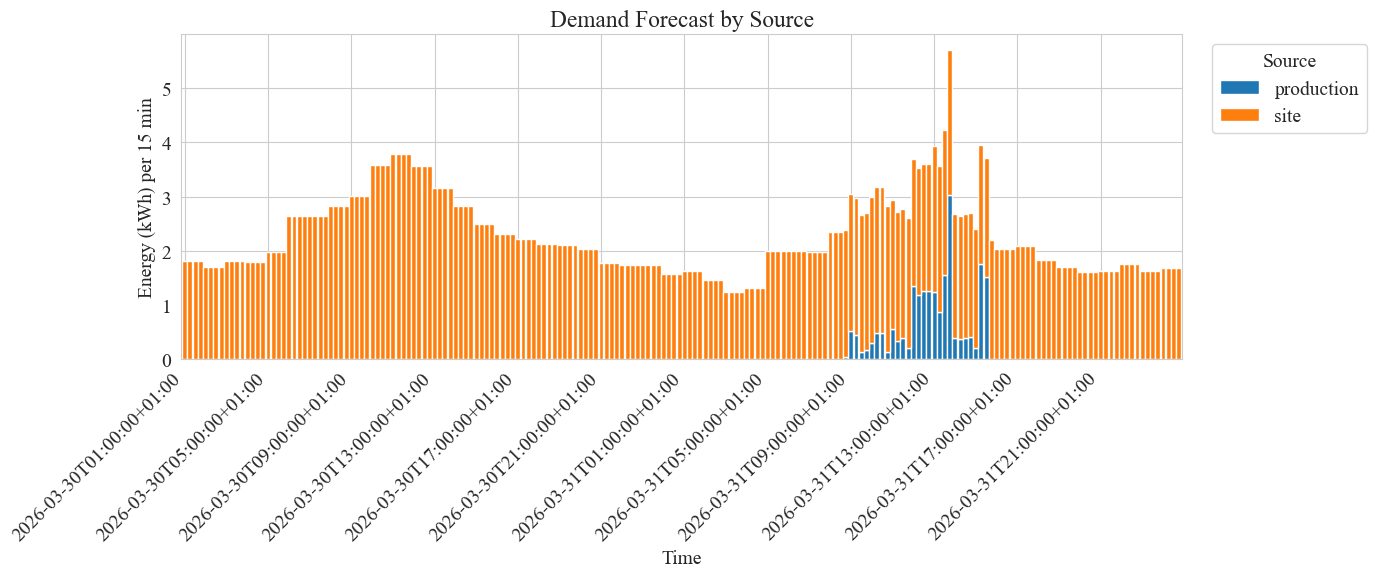

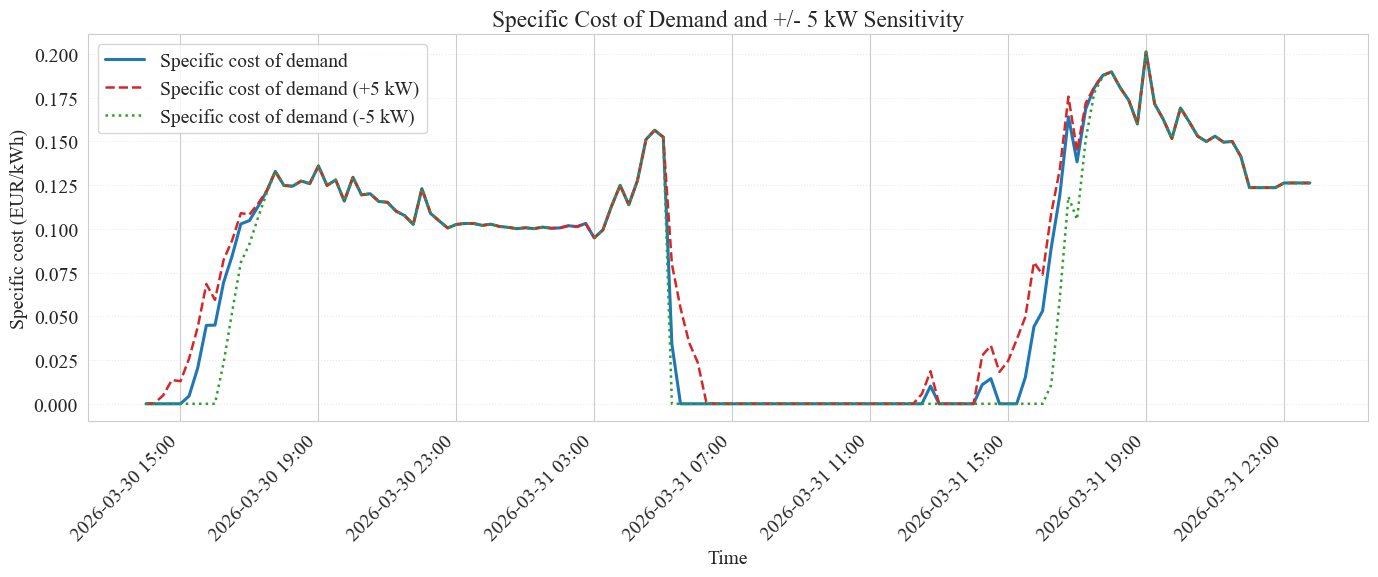

Saved processed data to outputs
Available figures:
- demand_cost_sensitivity.png
- demand_stacked.png
- residual_availability_stacked.png
- supply_energy_price_3d.png
- supply_minus_demand.png
- supply_shifted_by_demand.png
- supply_stacked.png
- supply_with_specific_demand_cost.png
- supply_with_specific_demand_cost_print.png


In [155]:
# Residual availability plot: used supply below zero, remaining supply above zero

plot_stacked_energy(
    residual_pivot,
    title="Residual Availability by Source",
    filename="residual_availability_stacked.png",
)
plt.show()

# Demand plot and saved outputs

plot_stacked_energy(demand_pivot, title="Demand Forecast by Source", filename="demand_stacked.png")
plt.show()

# Demand cost plot: base demand and +/- 5 kW sensitivity

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    demand_costs["Time"],
    demand_costs["Specific cost of demand (EUR/kWh)"],
    label="Specific cost of demand",
    color="#1f77b4",
    linewidth=2.2,
)
ax.plot(
    demand_costs["Time"],
    demand_costs["Specific cost of demand (+5 kW) (EUR/kWh)"],
    label="Specific cost of demand (+5 kW)",
    color="#d62728",
    linestyle="--",
    linewidth=1.8,
)
ax.plot(
    demand_costs["Time"],
    demand_costs["Specific cost of demand (-5 kW) (EUR/kWh)"],
    label="Specific cost of demand (-5 kW)",
    color="#2ca02c",
    linestyle=":",
    linewidth=1.8,
)
ax.set_title("Specific Cost of Demand and +/- 5 kW Sensitivity")
ax.set_xlabel("Time")
ax.set_ylabel("Specific cost (EUR/kWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(True, axis="y", linestyle=":", alpha=0.4)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "demand_cost_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

supply_df.to_csv(OUT_DIR / "supply_processed.csv", index=False)
demand_df.to_csv(OUT_DIR / "demand_processed.csv", index=False)
residual_availability.to_csv(OUT_DIR / "residual_availability.csv", index=False)
demand_costs.to_csv(OUT_DIR / "demand_costs.csv", index=False)
supply_pivot.to_csv(OUT_DIR / "supply_pivot.csv")
demand_pivot.to_csv(OUT_DIR / "demand_pivot.csv")

print('Saved processed data to', OUT_DIR)
print('Available figures:')
for figure in sorted(FIG_DIR.iterdir()):
    print("-", figure.name)


## Notes

1. Ensure JSON files exist in `energy_information_service/results/`, or set `RESULTS_DIR`, `SUPPLY_JSON`, and `DEMAND_JSON` in your environment.
2. Optional filters: set `FROM_TIME` / `TO_TIME` (ISO datetime) to restrict the analysis window.
3. All generated figures and derived CSV exports are written to `figs/` and `outputs/`.
